In [1]:
import pandas as pd

In [2]:
air_quality = pd.read_csv('air_quality.csv')

In [3]:
air_quality.info()

<class 'pandas.DataFrame'>
RangeIndex: 95685 entries, 0 to 95684
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date_time  95685 non-null  str    
 1   PM2.5      95685 non-null  float64
 2   PM10       95685 non-null  float64
 3   SO2        95685 non-null  float64
 4   NO2        95685 non-null  float64
 5   CO         95685 non-null  float64
 6   O3         95685 non-null  float64
 7   TEMP       95685 non-null  float64
 8   PRES       95685 non-null  float64
 9   DEWP       95685 non-null  float64
 10  RAIN       95685 non-null  float64
 11  wd         95685 non-null  str    
 12  WSPM       95685 non-null  float64
 13  station    95685 non-null  str    
dtypes: float64(11), str(3)
memory usage: 10.2 MB


In [4]:
air_quality.head()

,date_time,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013-03-01 00:00:00,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2013-03-01 01:00:00,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,2013-03-01 05:00:00,4.0,4.0,9.0,25.0,300.0,78.0,-2.4,1027.5,-21.3,0.0,NW,2.4,Dongsi
3,2013-03-01 06:00:00,5.0,5.0,10.0,29.0,400.0,67.0,-2.5,1028.2,-20.4,0.0,NW,2.2,Dongsi
4,2013-03-01 07:00:00,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,NNW,3.0,Dongsi


In [5]:
air_quality['date_time'] = pd.to_datetime(air_quality['date_time'])

In [6]:
air_quality['year'] = air_quality['date_time'].dt.year
air_quality['month'] = air_quality['date_time'].dt.month
air_quality['day'] = air_quality['date_time'].dt.day
air_quality['hour'] = air_quality['date_time'].dt.hour
air_quality['quarter'] = air_quality['date_time'].dt.quarter
air_quality['day_of_week_num'] = air_quality['date_time'].dt.dayofweek
air_quality['day_of_week_name'] = air_quality['date_time' ]. dt. day_name()

air_quality[['date_time', 'year', 'month', 'day', 'hour', 'quarter', 'day_of_week_num', 'day_of_week_name']]

,date_time,year,month,day,hour,quarter,day_of_week_num,day_of_week_name
0,2013-03-01 00:00:00,2013,3,1,0,1,4,Friday
1,2013-03-01 01:00:00,2013,3,1,1,1,4,Friday
2,2013-03-01 05:00:00,2013,3,1,5,1,4,Friday
3,2013-03-01 06:00:00,2013,3,1,6,1,4,Friday
4,2013-03-01 07:00:00,2013,3,1,7,1,4,Friday
...,...,...,...,...,...,...,...,...
95680,2017-02-28 15:00:00,2017,2,28,15,1,1,Tuesday
95681,2017-02-28 16:00:00,2017,2,28,16,1,1,Tuesday
95682,2017-02-28 21:00:00,2017,2,28,21,1,1,Tuesday
95683,2017-02-28 22:00:00,2017,2,28,22,1,1,Tuesday


In [7]:
air_quality[['day_of_week_num', 'day_of_week_name']].value_counts()

day_of_week_num  day_of_week_name
6                Sunday              13931
5                Saturday            13812
4                Friday              13782
3                Thursday            13633
0                Monday              13536
1                Tuesday             13523
2                Wednesday           13468
Name: count, dtype: int64

In [8]:
air_quality['date_time'].max()

Timestamp('2017-02-28 23:00:00')

In [9]:
air_quality['date_time'].min()

Timestamp('2013-03-01 00:00:00')

In [10]:
date_time_range = air_quality['date_time'].max() - air_quality['date_time'].min()

In [11]:
pd.Timedelta(days=256)

Timedelta('256 days 00:00:00')

In [12]:
date_time_range/pd.Timedelta(days=1)

1460.9583333333333

In [13]:
date_time_range/pd.Timedelta(days=365)

4.002625570776256

In [14]:
pd.Timestamp('2026/01/01')

Timestamp('2026-01-01 00:00:00')

In [15]:
air_quality['time_until_2026']=pd.Timestamp('2026/01/01') - air_quality['date_time']

In [16]:
air_quality['time_until_2026']/pd.Timedelta(days=1)

0        4689.000000
1        4688.958333
2        4688.791667
3        4688.750000
4        4688.708333
            ...     
95680    3228.375000
95681    3228.333333
95682    3228.125000
95683    3228.083333
95684    3228.041667
Name: time_until_2026, Length: 95685, dtype: float64

In [17]:
air_quality['time_until_2026_days']=air_quality['time_until_2026']/pd.Timedelta(days=1)

In [18]:
air_quality['time_until_2026_weeks']=air_quality['time_until_2026']/pd.Timedelta(weeks=1)

In [19]:
air_quality[['date_time', 'time_until_2026', 'time_until_2026_days', 'time_until_2026_weeks']]

,date_time,time_until_2026,time_until_2026_days,time_until_2026_weeks
0,2013-03-01 00:00:00,4689 days 00:00:00,4689.000000,669.857143
1,2013-03-01 01:00:00,4688 days 23:00:00,4688.958333,669.851190
2,2013-03-01 05:00:00,4688 days 19:00:00,4688.791667,669.827381
3,2013-03-01 06:00:00,4688 days 18:00:00,4688.750000,669.821429
4,2013-03-01 07:00:00,4688 days 17:00:00,4688.708333,669.815476
...,...,...,...,...
95680,2017-02-28 15:00:00,3228 days 09:00:00,3228.375000,461.196429
95681,2017-02-28 16:00:00,3228 days 08:00:00,3228.333333,461.190476
95682,2017-02-28 21:00:00,3228 days 03:00:00,3228.125000,461.160714
95683,2017-02-28 22:00:00,3228 days 02:00:00,3228.083333,461.154762


In [20]:
air_quality['prior_2026_ind']=air_quality['date_time']<pd.Timestamp('2016/01/01')

In [21]:
air_quality[['date_time', 'prior_2026_ind']]

,date_time,prior_2026_ind
0,2013-03-01 00:00:00,True
1,2013-03-01 01:00:00,True
2,2013-03-01 05:00:00,True
3,2013-03-01 06:00:00,True
4,2013-03-01 07:00:00,True
...,...,...
95680,2017-02-28 15:00:00,False
95681,2017-02-28 16:00:00,False
95682,2017-02-28 21:00:00,False
95683,2017-02-28 22:00:00,False


In [22]:
print(air_quality.head())
air_quality = air_quality.set_index(air_quality['date_time'])

            date_time  PM2.5  PM10   SO2   NO2     CO    O3  TEMP    PRES  \
0 2013-03-01 00:00:00    9.0   9.0   3.0  17.0  300.0  89.0  -0.5  1024.5   
1 2013-03-01 01:00:00    4.0   4.0   3.0  16.0  300.0  88.0  -0.7  1025.1   
2 2013-03-01 05:00:00    4.0   4.0   9.0  25.0  300.0  78.0  -2.4  1027.5   
3 2013-03-01 06:00:00    5.0   5.0  10.0  29.0  400.0  67.0  -2.5  1028.2   
4 2013-03-01 07:00:00    3.0   6.0  12.0  40.0  400.0  52.0  -1.4  1029.5   

   DEWP  ...  month day  hour quarter  day_of_week_num  day_of_week_name  \
0 -21.4  ...      3   1     0       1                4            Friday   
1 -22.1  ...      3   1     1       1                4            Friday   
2 -21.3  ...      3   1     5       1                4            Friday   
3 -20.4  ...      3   1     6       1                4            Friday   
4 -20.4  ...      3   1     7       1                4            Friday   

     time_until_2026  time_until_2026_days  time_until_2026_weeks  \
0 4689 days

In [23]:
air_quality.set_index('date_time', inplace=True)

if 'date_time' in air_quality.columns:
    air_quality.drop(columns='date_time', inplace=True)

In [24]:
air_quality.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,...,3,1,0,1,4,Friday,4689 days 00:00:00,4689.000000,669.857143,True
2013-03-01 01:00:00,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,...,3,1,1,1,4,Friday,4688 days 23:00:00,4688.958333,669.851190,True
2013-03-01 05:00:00,4.0,4.0,9.0,25.0,300.0,78.0,-2.4,1027.5,-21.3,0.0,...,3,1,5,1,4,Friday,4688 days 19:00:00,4688.791667,669.827381,True
2013-03-01 06:00:00,5.0,5.0,10.0,29.0,400.0,67.0,-2.5,1028.2,-20.4,0.0,...,3,1,6,1,4,Friday,4688 days 18:00:00,4688.750000,669.821429,True
2013-03-01 07:00:00,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,...,3,1,7,1,4,Friday,4688 days 17:00:00,4688.708333,669.815476,True


In [25]:
air_quality = air_quality.sort_index()
air_quality.loc['2013-01':'2013-02']

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,


<Axes: xlabel='date_time'>

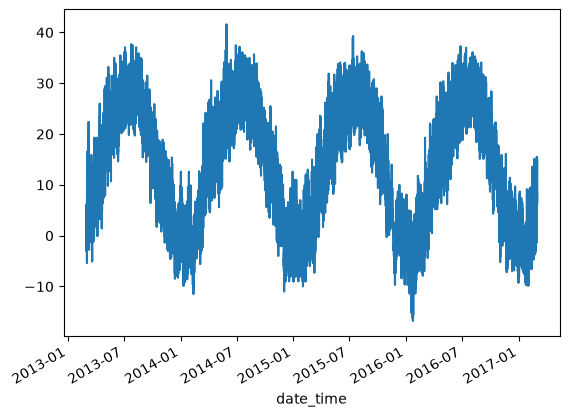

In [26]:
air_quality.loc['2013':, 'TEMP'].plot()

In [38]:
air_quality = air_quality[~air_quality.index.duplicated(keep='first')]

In [39]:
air_quality.asfreq(freq='1W')

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,
2013-03-03,84.0,97.0,39.0,80.0,2299.0,4.0,-2.200,1022.3,-12.8,0.0,...,3.0,3.0,0.0,1.0,6.0,Sunday,4687 days,4687.0,669.571429,True
2013-03-10,3.0,8.0,3.0,7.0,400.0,96.0,3.400,1018.9,-18.1,0.0,...,3.0,10.0,0.0,1.0,6.0,Sunday,4680 days,4680.0,668.571429,True
2013-03-17,176.0,208.0,40.0,119.0,2100.0,107.0,7.100,1010.1,1.6,0.0,...,3.0,17.0,0.0,1.0,6.0,Sunday,4673 days,4673.0,667.571429,True
2013-03-24,5.0,18.0,3.0,14.0,400.0,83.0,2.900,1015.4,-15.7,0.0,...,3.0,24.0,0.0,1.0,6.0,Sunday,4666 days,4666.0,666.571429,True
2013-03-31,85.0,94.0,13.0,68.0,900.0,15.0,4.200,1019.9,0.7,0.0,...,3.0,31.0,0.0,1.0,6.0,Sunday,4659 days,4659.0,665.571429,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-01-29,244.0,323.0,7.0,69.0,3700.0,2.0,-3.525,1018.0,-6.5,0.0,...,1.0,29.0,0.0,1.0,6.0,Sunday,3259 days,3259.0,465.571429,False
2017-02-05,3.0,5.0,8.0,31.0,400.0,50.0,5.000,1015.7,-12.0,0.0,...,2.0,5.0,0.0,1.0,6.0,Sunday,3252 days,3252.0,464.571429,False
2017-02-12,303.0,383.0,105.0,102.0,2300.0,11.0,-3.200,1023.6,-12.9,0.0,...,2.0,12.0,0.0,1.0,6.0,Sunday,3245 days,3245.0,463.571429,False


In [40]:
air_quality[air_quality['PM2.5'].isna()]

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,


In [50]:
air_quality.asfreq(freq='1W-FRI')

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,
2013-03-01,9.0,9.0,3.0,17.0,300.0,89.0,-0.500,1024.50,-21.4,0.0,...,3.0,1.0,0.0,1.0,4.0,Friday,4689 days,4689.0,669.857143,True
2013-03-08,264.0,324.0,69.0,167.0,4400.0,107.0,6.900,996.20,-1.8,0.0,...,3.0,8.0,0.0,1.0,4.0,Friday,4682 days,4682.0,668.857143,True
2013-03-15,159.0,163.0,54.0,101.0,1800.0,68.0,1.300,1019.70,-3.2,0.0,...,3.0,15.0,0.0,1.0,4.0,Friday,4675 days,4675.0,667.857143,True
2013-03-22,173.0,180.0,31.0,94.0,1600.0,21.0,5.400,1009.60,-2.4,0.0,...,3.0,22.0,0.0,1.0,4.0,Friday,4668 days,4668.0,666.857143,True
2013-03-29,87.0,158.0,23.0,122.0,1500.0,4.0,3.200,1014.10,-8.2,0.0,...,3.0,29.0,0.0,1.0,4.0,Friday,4661 days,4661.0,665.857143,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-01-27,6.0,6.0,4.0,7.0,200.0,59.0,0.425,1022.75,-16.3,0.0,...,1.0,27.0,0.0,1.0,4.0,Friday,3261 days,3261.0,465.857143,False
2017-02-03,139.0,155.0,32.0,101.0,2700.0,2.0,-4.600,1018.20,-16.8,0.0,...,2.0,3.0,0.0,1.0,4.0,Friday,3254 days,3254.0,464.857143,False
2017-02-10,12.0,34.0,2.0,16.0,200.0,70.0,-1.800,1024.00,-19.8,0.0,...,2.0,10.0,0.0,1.0,4.0,Friday,3247 days,3247.0,463.857143,False


In [41]:
air_quality_1W_asfreq = air_quality.asfreq(freq='1W-FRI', method='ffill')

In [51]:
air_quality_1W_asfreq_bfill = air_quality.asfreq(freq='1W-FRI', method='bfill')

In [54]:
air_quality_1w_resample = air_quality.resample(rule='1W-FRI').last()

In [55]:
air_quality_1w_resample

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,
2013-03-01,8.0,14.0,16.0,58.0,600.0,39.0,-0.5,1032.8,-19.7,0.0,...,3,1,23,1,4,Friday,4688 days 01:00:00,4688.041667,669.720238,True
2013-03-08,57.0,76.0,57.0,55.0,1800.0,92.0,5.3,999.2,-5.1,0.0,...,3,8,23,1,4,Friday,4681 days 01:00:00,4681.041667,668.720238,True
2013-03-15,335.0,352.0,53.0,151.0,3799.0,71.0,6.1,1013.5,0.8,0.0,...,3,15,23,1,4,Friday,4674 days 01:00:00,4674.041667,667.720238,True
2013-03-22,63.0,74.0,18.0,56.0,1600.0,25.0,1.9,1013.7,-4.4,0.0,...,3,22,23,1,4,Friday,4667 days 01:00:00,4667.041667,666.720238,True
2013-03-29,58.0,81.0,49.0,62.0,900.0,17.0,3.9,1019.4,-7.3,0.0,...,3,29,23,1,4,Friday,4660 days 01:00:00,4660.041667,665.720238,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-03,342.0,386.0,61.0,139.0,4200.0,2.0,-0.4,1012.8,-11.2,0.0,...,2,3,23,1,4,Friday,3253 days 01:00:00,3253.041667,464.720238,False
2017-02-10,9.0,27.0,5.0,36.0,500.0,57.0,0.9,1025.3,-22.9,0.0,...,2,10,23,1,4,Friday,3246 days 01:00:00,3246.041667,463.720238,False
2017-02-17,52.0,124.0,15.0,77.0,900.0,9.0,2.1,1019.1,-15.5,0.0,...,2,17,23,1,4,Friday,3239 days 01:00:00,3239.041667,462.720238,False


In [67]:
air_quality_1w_resample['TEMP_MAX'] = air_quality['TEMP'].resample('1D').max()
air_quality_1w_resample['TEMP_MIN'] = air_quality['TEMP'].resample('2D').min()

In [68]:
air_quality_1w_resample.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind,TEMP_MAX,TEMP_MIN
date_time,,,,,,,,,,,,,,,,,,,,,
2013-03-01,8.0,14.0,16.0,58.0,600.0,39.0,6.2,1032.8,-19.7,0.0,...,23,1,4,Friday,4688 days 01:00:00,4688.041667,669.720238,True,6.2,-2.5
2013-03-08,57.0,76.0,57.0,55.0,1800.0,92.0,21.7,999.2,-5.1,0.0,...,23,1,4,Friday,4681 days 01:00:00,4681.041667,668.720238,True,21.7,NaN
2013-03-15,335.0,352.0,53.0,151.0,3799.0,71.0,12.0,1013.5,0.8,0.0,...,23,1,4,Friday,4674 days 01:00:00,4674.041667,667.720238,True,12.0,-1.2
2013-03-22,63.0,74.0,18.0,56.0,1600.0,25.0,10.2,1013.7,-4.4,0.0,...,23,1,4,Friday,4667 days 01:00:00,4667.041667,666.720238,True,10.2,NaN
2013-03-29,58.0,81.0,49.0,62.0,900.0,17.0,9.9,1019.4,-7.3,0.0,...,23,1,4,Friday,4660 days 01:00:00,4660.041667,665.720238,True,9.9,2.0


In [70]:
air_quality.head(48)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,...,3,1,0,1,4,Friday,4689 days 00:00:00,4689.000000,669.857143,True
2013-03-01 01:00:00,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,...,3,1,1,1,4,Friday,4688 days 23:00:00,4688.958333,669.851190,True
2013-03-01 02:00:00,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,...,3,1,2,1,4,Friday,4688 days 22:00:00,4688.916667,669.845238,True
2013-03-01 03:00:00,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,...,3,1,3,1,4,Friday,4688 days 21:00:00,4688.875000,669.839286,True
2013-03-01 04:00:00,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,...,3,1,4,1,4,Friday,4688 days 20:00:00,4688.833333,669.833333,True
2013-03-01 05:00:00,10.0,10.0,12.0,15.0,400.0,70.0,-2.4,1027.5,-21.3,0.0,...,3,1,5,1,4,Friday,4688 days 19:00:00,4688.791667,669.827381,True
2013-03-01 06:00:00,8.0,19.0,12.0,14.0,400.0,72.0,-2.5,1028.2,-20.4,0.0,...,3,1,6,1,4,Friday,4688 days 18:00:00,4688.750000,669.821429,True
2013-03-01 07:00:00,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,...,3,1,7,1,4,Friday,4688 days 17:00:00,4688.708333,669.815476,True
2013-03-01 08:00:00,3.0,6.0,12.0,41.0,500.0,54.0,-0.3,1030.4,-21.2,0.0,...,3,1,8,1,4,Friday,4688 days 16:00:00,4688.666667,669.809524,True


In [71]:
air_quality['TEMP'].resample('2D').min()

date_time
2013-03-01   -2.5
2013-03-03   -5.2
2013-03-05   -0.2
2013-03-07    0.5
2013-03-09   -2.1
             ... 
2017-02-20   -2.5
2017-02-22   -3.7
2017-02-24   -2.2
2017-02-26   -1.5
2017-02-28    5.3
Freq: 2D, Name: TEMP, Length: 731, dtype: float64

In [78]:
air_quality.loc['2013-03-07':'2013-03-08']

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,
2013-03-07 00:00:00,251.0,280.0,112.0,158.0,4400.0,22.0,2.9,1009.2,-3.2,0.0,...,3,7,0,1,3,Thursday,4683 days 00:00:00,4683.000000,669.000000,True
2013-03-07 01:00:00,284.0,391.0,101.0,160.0,5200.0,26.0,4.2,1005.3,-2.9,0.0,...,3,7,1,1,3,Thursday,4682 days 23:00:00,4682.958333,668.994048,True
2013-03-07 02:00:00,259.0,276.0,55.0,119.0,4200.0,24.0,3.3,1008.9,-3.3,0.0,...,3,7,2,1,3,Thursday,4682 days 22:00:00,4682.916667,668.988095,True
2013-03-07 03:00:00,222.0,258.0,44.0,105.0,4299.0,24.0,1.2,1008.3,-3.9,0.0,...,3,7,3,1,3,Thursday,4682 days 21:00:00,4682.875000,668.982143,True
2013-03-07 04:00:00,242.0,266.0,86.0,144.0,4400.0,22.0,0.9,1008.5,-2.5,0.0,...,3,7,4,1,3,Thursday,4682 days 20:00:00,4682.833333,668.976190,True
2013-03-07 05:00:00,211.0,226.0,19.0,94.0,4500.0,24.0,0.5,1008.6,-3.4,0.0,...,3,7,5,1,3,Thursday,4682 days 19:00:00,4682.791667,668.970238,True
2013-03-07 06:00:00,131.0,152.0,39.0,100.0,4299.0,26.0,1.3,1004.7,-3.2,0.0,...,3,7,6,1,3,Thursday,4682 days 18:00:00,4682.750000,668.964286,True
2013-03-07 07:00:00,261.0,281.0,78.0,165.0,6200.0,22.0,2.6,1008.7,-1.8,0.0,...,3,7,7,1,3,Thursday,4682 days 17:00:00,4682.708333,668.958333,True
2013-03-07 08:00:00,154.0,187.0,75.0,171.0,7000.0,26.0,8.6,1004.7,-2.4,0.0,...,3,7,8,1,3,Thursday,4682 days 16:00:00,4682.666667,668.952381,True


In [84]:
air_quality.resample('6h', label='right').agg({'PM2.5':'first',
                                'PM10':'max',
                                'CO':'min',
                                'TEMP':'last',
                                'hour':'sum'})

,PM2.5,PM10,CO,TEMP,hour
date_time,,,,,
2013-03-01 06:00:00,9.0,29.0,300.0,-2.4,15
2013-03-01 12:00:00,8.0,23.0,300.0,2.9,51
2013-03-01 18:00:00,9.0,22.0,300.0,4.4,87
2013-03-02 00:00:00,11.0,28.0,400.0,-0.5,123
2013-03-02 06:00:00,16.0,29.0,400.0,-2.4,15
...,...,...,...,...,...
2017-02-28 00:00:00,48.0,141.0,800.0,10.9,123
2017-02-28 06:00:00,62.0,104.0,400.0,5.3,15
2017-02-28 12:00:00,14.0,37.0,400.0,13.5,51


In [81]:
air_quality.head(24)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,...,3,1,0,1,4,Friday,4689 days 00:00:00,4689.000000,669.857143,True
2013-03-01 01:00:00,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,...,3,1,1,1,4,Friday,4688 days 23:00:00,4688.958333,669.851190,True
2013-03-01 02:00:00,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,...,3,1,2,1,4,Friday,4688 days 22:00:00,4688.916667,669.845238,True
2013-03-01 03:00:00,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,...,3,1,3,1,4,Friday,4688 days 21:00:00,4688.875000,669.839286,True
2013-03-01 04:00:00,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,...,3,1,4,1,4,Friday,4688 days 20:00:00,4688.833333,669.833333,True
2013-03-01 05:00:00,10.0,10.0,12.0,15.0,400.0,70.0,-2.4,1027.5,-21.3,0.0,...,3,1,5,1,4,Friday,4688 days 19:00:00,4688.791667,669.827381,True
2013-03-01 06:00:00,8.0,19.0,12.0,14.0,400.0,72.0,-2.5,1028.2,-20.4,0.0,...,3,1,6,1,4,Friday,4688 days 18:00:00,4688.750000,669.821429,True
2013-03-01 07:00:00,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,...,3,1,7,1,4,Friday,4688 days 17:00:00,4688.708333,669.815476,True
2013-03-01 08:00:00,3.0,6.0,12.0,41.0,500.0,54.0,-0.3,1030.4,-21.2,0.0,...,3,1,8,1,4,Friday,4688 days 16:00:00,4688.666667,669.809524,True


In [86]:
air_quality['TEMP'].rolling(window=3).min()

date_time
2013-03-01 00:00:00     NaN
2013-03-01 01:00:00     NaN
2013-03-01 02:00:00    -1.2
2013-03-01 03:00:00    -1.4
2013-03-01 04:00:00    -1.9
                       ... 
2017-02-28 19:00:00    12.8
2017-02-28 20:00:00    11.1
2017-02-28 21:00:00    10.8
2017-02-28 22:00:00    10.5
2017-02-28 23:00:00     8.6
Name: TEMP, Length: 34618, dtype: float64

In [87]:
air_quality['TEMP'].rolling(window=3, min_periods=2).min()

date_time
2013-03-01 00:00:00     NaN
2013-03-01 01:00:00    -0.7
2013-03-01 02:00:00    -1.2
2013-03-01 03:00:00    -1.4
2013-03-01 04:00:00    -1.9
                       ... 
2017-02-28 19:00:00    12.8
2017-02-28 20:00:00    11.1
2017-02-28 21:00:00    10.8
2017-02-28 22:00:00    10.5
2017-02-28 23:00:00     8.6
Name: TEMP, Length: 34618, dtype: float64

In [97]:
air_quality['TEMP'].rolling(window='3D').mean()

date_time
2013-03-01 00:00:00   -0.500000
2013-03-01 01:00:00   -0.600000
2013-03-01 02:00:00   -0.800000
2013-03-01 03:00:00   -0.950000
2013-03-01 04:00:00   -1.140000
                         ...   
2017-02-28 19:00:00    8.533333
2017-02-28 20:00:00    8.548611
2017-02-28 21:00:00    8.575000
2017-02-28 22:00:00    8.606944
2017-02-28 23:00:00    8.661111
Name: TEMP, Length: 34618, dtype: float64

In [89]:
air_quality.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,...,3,1,0,1,4,Friday,4689 days 00:00:00,4689.000000,669.857143,True
2013-03-01 01:00:00,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,...,3,1,1,1,4,Friday,4688 days 23:00:00,4688.958333,669.851190,True
2013-03-01 02:00:00,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,...,3,1,2,1,4,Friday,4688 days 22:00:00,4688.916667,669.845238,True
2013-03-01 03:00:00,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,...,3,1,3,1,4,Friday,4688 days 21:00:00,4688.875000,669.839286,True
2013-03-01 04:00:00,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,...,3,1,4,1,4,Friday,4688 days 20:00:00,4688.833333,669.833333,True


In [101]:
air_quality.shift(2)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2013-03-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2013-03-01 02:00:00,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,...,3.0,1.0,0.0,1.0,4.0,Friday,4689 days 00:00:00,4689.000000,669.857143,True
2013-03-01 03:00:00,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,...,3.0,1.0,1.0,1.0,4.0,Friday,4688 days 23:00:00,4688.958333,669.851190,True
2013-03-01 04:00:00,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,...,3.0,1.0,2.0,1.0,4.0,Friday,4688 days 22:00:00,4688.916667,669.845238,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-28 19:00:00,12.0,47.0,3.0,4.0,400.0,69.0,14.1,1009.0,-17.1,0.0,...,2.0,28.0,17.0,1.0,1.0,Tuesday,3228 days 07:00:00,3228.291667,461.184524,False
2017-02-28 20:00:00,12.0,41.0,3.0,10.0,400.0,64.0,13.4,1009.4,-16.5,0.0,...,2.0,28.0,18.0,1.0,1.0,Tuesday,3228 days 06:00:00,3228.250000,461.178571,False
2017-02-28 21:00:00,14.0,58.0,4.0,19.0,500.0,56.0,12.8,1009.9,-17.0,0.0,...,2.0,28.0,19.0,1.0,1.0,Tuesday,3228 days 05:00:00,3228.208333,461.172619,False


In [102]:
air_quality.shift(-3)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,month,day,hour,quarter,day_of_week_num,day_of_week_name,time_until_2026,time_until_2026_days,time_until_2026_weeks,prior_2026_ind
date_time,,,,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,...,3.0,1.0,3.0,1.0,4.0,Friday,4688 days 21:00:00,4688.875000,669.839286,True
2013-03-01 01:00:00,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,...,3.0,1.0,4.0,1.0,4.0,Friday,4688 days 20:00:00,4688.833333,669.833333,True
2013-03-01 02:00:00,10.0,10.0,12.0,15.0,400.0,70.0,-2.4,1027.5,-21.3,0.0,...,3.0,1.0,5.0,1.0,4.0,Friday,4688 days 19:00:00,4688.791667,669.827381,True
2013-03-01 03:00:00,8.0,19.0,12.0,14.0,400.0,72.0,-2.5,1028.2,-20.4,0.0,...,3.0,1.0,6.0,1.0,4.0,Friday,4688 days 18:00:00,4688.750000,669.821429,True
2013-03-01 04:00:00,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,...,3.0,1.0,7.0,1.0,4.0,Friday,4688 days 17:00:00,4688.708333,669.815476,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-28 19:00:00,15.0,42.0,5.0,52.0,600.0,44.0,10.5,1014.4,-12.9,0.0,...,2.0,28.0,22.0,1.0,1.0,Tuesday,3228 days 02:00:00,3228.083333,461.154762,False
2017-02-28 20:00:00,30.0,71.0,11.0,87.0,1200.0,4.0,8.6,1014.1,-15.9,0.0,...,2.0,28.0,23.0,1.0,1.0,Tuesday,3228 days 01:00:00,3228.041667,461.148810,False
2017-02-28 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
